In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import RELLISUR_DataLoader as rel
import srmodels as srm
import utils as u
from torch.cuda.amp import autocast, GradScaler

In [2]:
device = 'cuda'

In [3]:
batch_sizes = {
    "train" : 64,
    "val" : 3,
    "test" : 3
}

train_ds, val_ds, test_ds = rel.get_LLE_datasets_with_hist()
train_dl, val_dl, test_dl = rel.get_SR_dataloaders(train_ds, val_ds, test_ds, batch_sizes)

3610


In [4]:
model = srm.SimpleLLE2().to(device)
criterion = u.SSIMLoss(alpha=0.75)
optimizer = optim.AdamW(model.parameters(), lr=0.0001) 

In [5]:
u.training_loop(model, criterion, optimizer, 200, train_dl, val_dl, device)

Epoch [1/200], Train Loss: 0.406544, Val Loss: 0.298544,  PSNR: -10.482890
Epoch [2/200], Train Loss: 0.316903, Val Loss: 0.294426,  PSNR: -9.680195
Epoch [3/200], Train Loss: 0.279943, Val Loss: 0.258581,  PSNR: -10.951533
Epoch [4/200], Train Loss: 0.252045, Val Loss: 0.231983,  PSNR: -12.269325
Epoch [5/200], Train Loss: 0.230884, Val Loss: 0.212673,  PSNR: -13.636112
Epoch [6/200], Train Loss: 0.210231, Val Loss: 0.200254,  PSNR: -14.600533
Epoch [7/200], Train Loss: 0.197996, Val Loss: 0.189321,  PSNR: -15.365437
Epoch [8/200], Train Loss: 0.185573, Val Loss: 0.181980,  PSNR: -15.858021
Epoch [9/200], Train Loss: 0.176904, Val Loss: 0.168702,  PSNR: -16.612004
Epoch [10/200], Train Loss: 0.168019, Val Loss: 0.165089,  PSNR: -16.765151
Epoch [11/200], Train Loss: 0.164236, Val Loss: 0.160774,  PSNR: -17.060606
Epoch [12/200], Train Loss: 0.162703, Val Loss: 0.157457,  PSNR: -17.352747
Epoch [13/200], Train Loss: 0.160427, Val Loss: 0.160785,  PSNR: -17.301566
Epoch [14/200], Train 

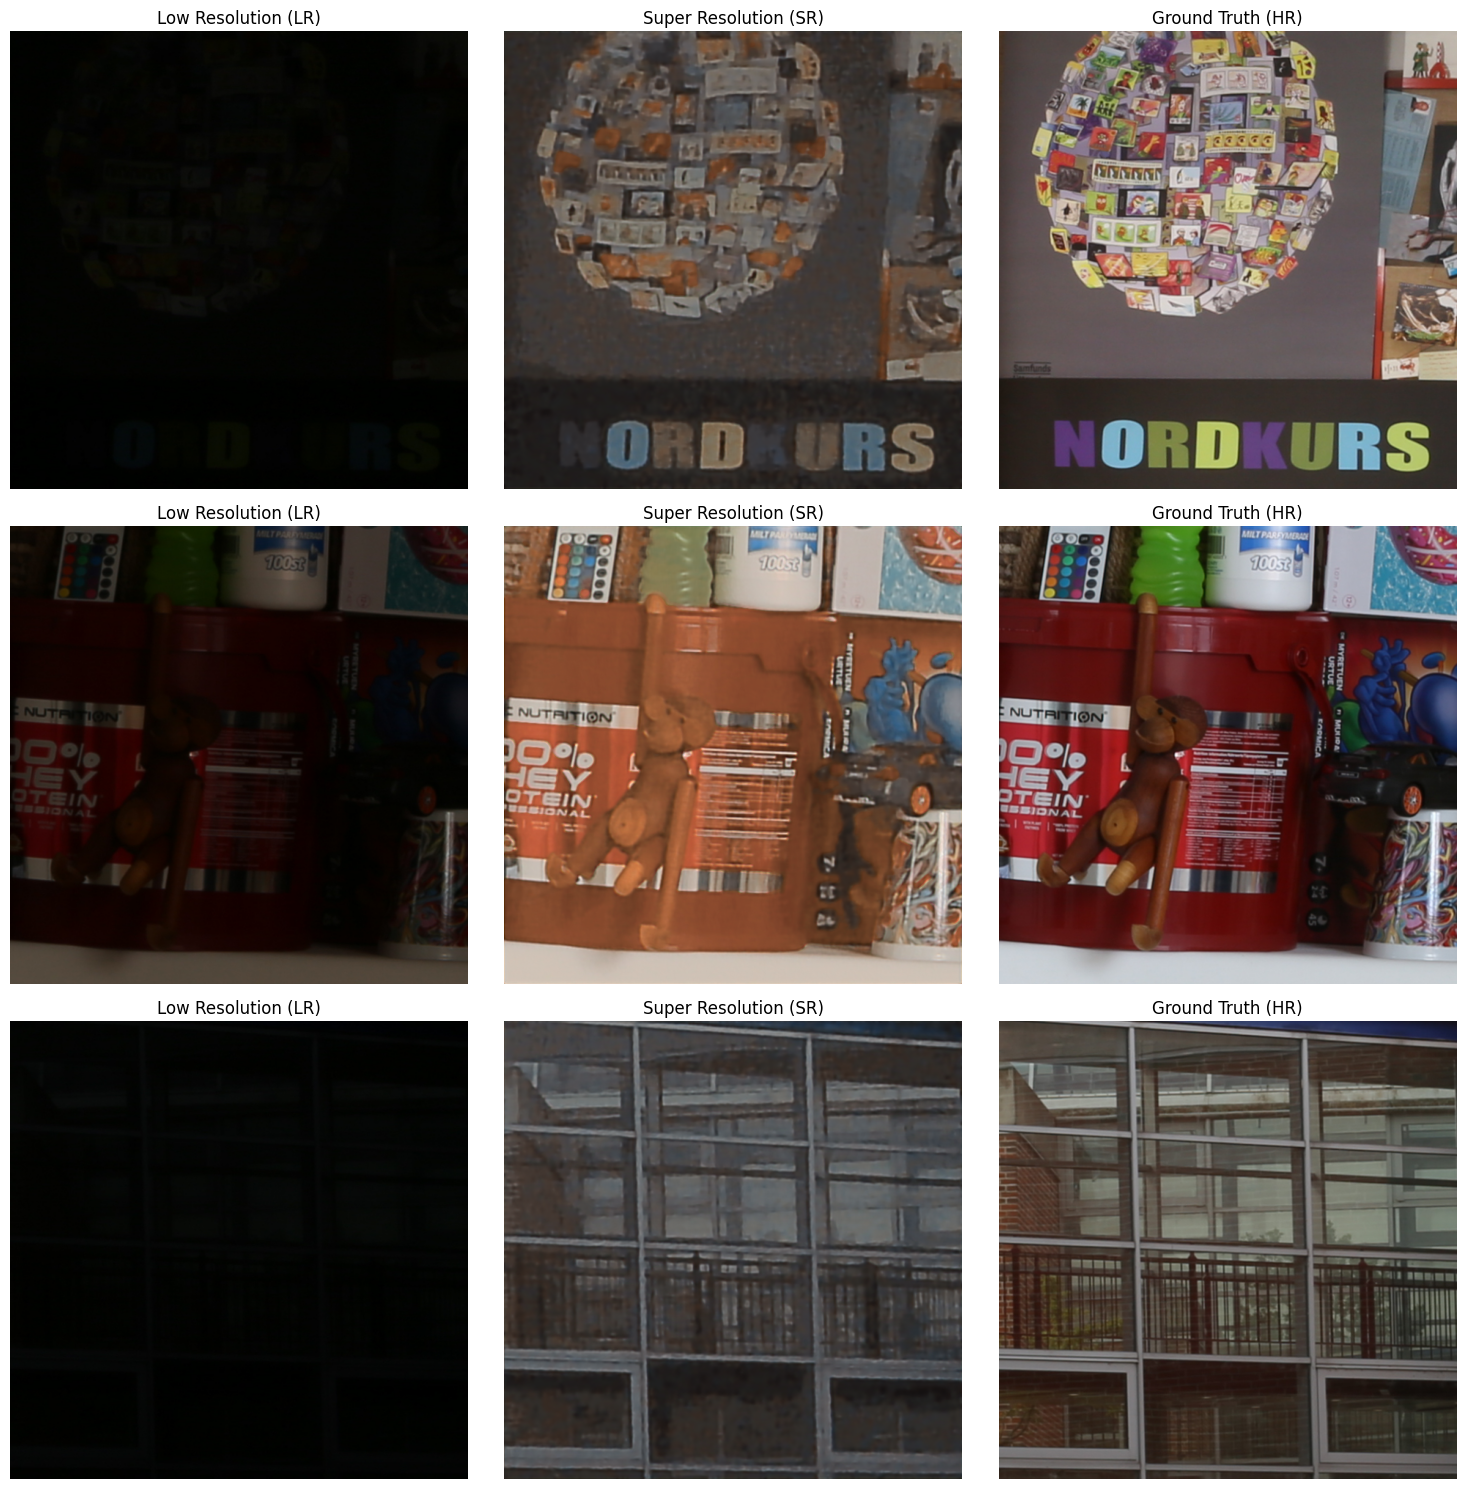

In [6]:
u.visualize_results(model, val_dl, device, num_samples=3)

3610
Epoch [1/3], Train Loss: 0.355029, Val Loss: 0.256184,  PSNR: -13.145589
Epoch [2/3], Train Loss: 0.233705, Val Loss: 0.246419,  PSNR: -13.707653
Epoch [3/3], Train Loss: 0.223840, Val Loss: 0.244419,  PSNR: -13.799147


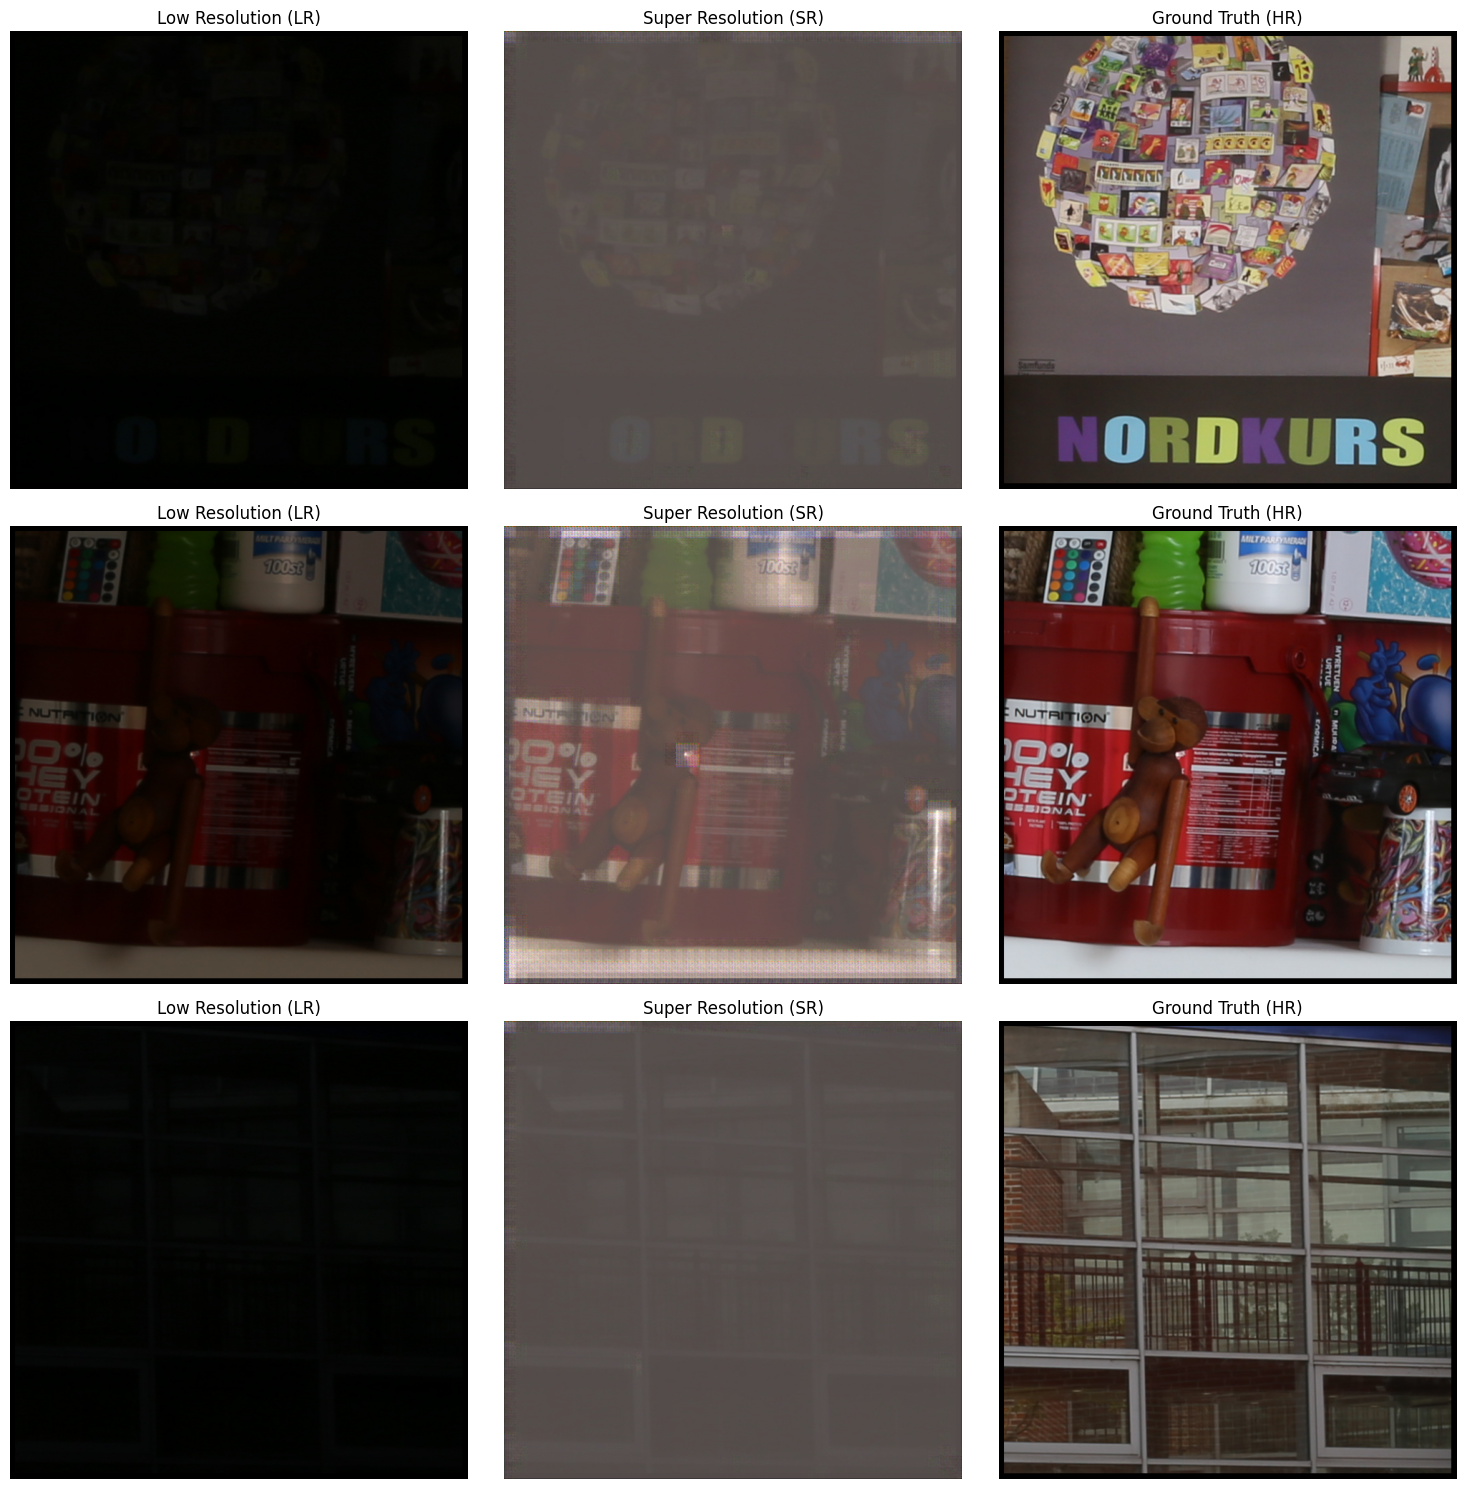

In [5]:
batch_sizes = {
    "train" : 128,
    "val" : 3,
    "test" : 3
}

train_ds, val_ds, test_ds = rel.get_LLE_datasets_with_hist()
train_dl, val_dl, test_dl = rel.get_SR_dataloaders(train_ds, val_ds, test_ds, batch_sizes)
model = srm.ResNetLLE_Light().to(device)
criterion = u.SSIMLoss(alpha=0.75)
optimizer = optim.AdamW(model.parameters(), lr=0.001) 
u.training_loop(model, criterion, optimizer, 3, train_dl, val_dl, device)
u.visualize_results(model, val_dl, device, num_samples=3)